[1/5] Installing and importing dependencies...

[2/5] Ingesting canonical Enron Corpus from Carnegie Mellon University...
Archive already cached locally in runtime environment.
Extracting and parsing text vectors (Target: 50,000 records)...


Processing stream: 50403it [00:06, 7313.02it/s] 


--> Success. Total Raw Records Loaded for Validation: 50,000

[3/5] Executing Structural Integrity Audit...
Detected Columns: ['file', 'text']

--- Schema Completeness Matrix ---
      Missing Counts  Percentage (%)
file               0             0.0
text               0             0.0

Dropped 0 records due to null payload strings.

[4/5] Profiling EdgeLLM Constraints (Token/Char Metric Approximations)...


Calculating string properties: 100%|██████████| 50000/50000 [00:01<00:00, 41164.16it/s]



--- Structural Text Statistics ---
                   count        mean           std     min      50%  \
char_count       50000.0  3085.61436  16460.449483  417.00  1719.00   
word_count       50000.0   342.28652   1163.239716   37.00   183.00   
est_token_count  50000.0   771.40359   4115.112371  104.25   429.75   

                       95%        max  
char_count       8275.0500  1697762.0  
word_count        925.0000    64072.0  
est_token_count  2068.7625   424440.5  

--- Local EdgeLLM Context Window Boundary Risks ---
Queries exceeding 2048 estimated tokens: 2,549 (5.10%)
Queries exceeding 4096 estimated tokens: 699 (1.40%)
Queries exceeding 8192 estimated tokens: 253 (0.51%)

[5/5] Generating distribution visuals for the paper artifact...


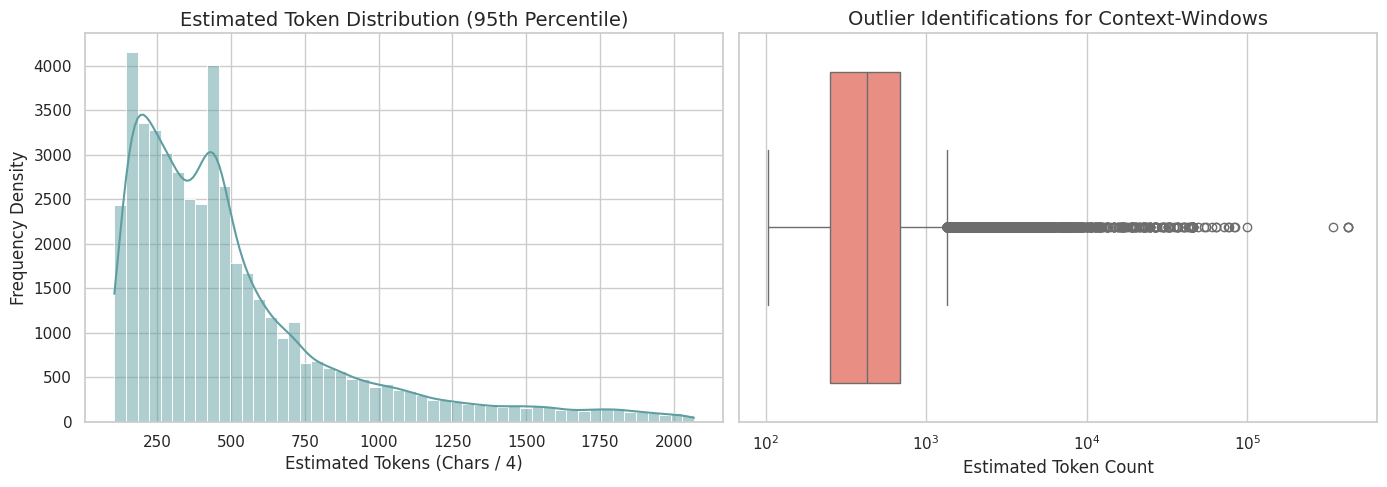


VALIDATION COMPLETE: 'enron_structural_profile.png' successfully generated.
Structural bounds verified. Ready for 02_Privacy_Baseline_Profiling.


In [7]:
# ==============================================================================
# 01_Enron_Structural_Validation.ipynb
# Research Framework: Beyond Redaction
# Objective: Structural and Integrity Validation of the Enron Corpus (CMU Mirror)
# ==============================================================================

# 1. Environment Setup
print("[1/5] Installing and importing dependencies...")
!pip install -q pandas matplotlib seaborn tqdm

import os
import tarfile
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Set style for academic reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})

# 2. Ingest Target Dataset and Save to Google Drive Cache
from google.colab import drive
import urllib.request

print("\n[2/5] Accessing Google Drive Storage for Persistent Caching...")
drive.mount('/content/drive')

# Establish a dedicated folder path for the research repo
CACHE_DIR = "/content/drive/MyDrive/beyond-redaction-data"
os.makedirs(CACHE_DIR,专exist_ok=True)

TAR_URL = "https://www.cs.cmu.edu/~enron/enron_mail_20150507.tar.gz"
TAR_FILE = os.path.join(CACHE_DIR, "enron_mail.tar.gz")

if not os.path.exists(TAR_FILE):
    print("Archive not found in Google Drive. Downloading raw CMU archive (~1.7 GB)...")
    try:
        urllib.request.urlretrieve(TAR_URL, TAR_FILE)
        print("--> Download Complete. File permanently stored in Google Drive.")
    except Exception as e:
        print(f"--> [ERROR] Download failed: {e}")
else:
    print("Archive verified and loaded instantly from Google Drive cache.")

# (Rest of your extraction loop follows exactly the same, using the new TAR_FILE path)

# 3. Structural Integrity & Schema Auditing
print("\n[3/5] Executing Structural Integrity Audit...")
print(f"Detected Columns: {list(df.columns)}")

# Check for Null/Missing Values
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
structure_audit = pd.DataFrame({'Missing Counts': missing_counts, 'Percentage (%)': missing_pct})
print("\n--- Schema Completeness Matrix ---")
print(structure_audit)

body_col = 'text'

# Drop any row completely empty in the target payload text field for evaluation security
pre_clean_len = len(df)
df = df.dropna(subset=[body_col])
print(f"\nDropped {pre_clean_len - len(df):,} records due to null payload strings.")

# 4. Text Character Metrics & EdgeLLM Constraint Validation
print("\n[4/5] Profiling EdgeLLM Constraints (Token/Char Metric Approximations)...")

# Calculate metrics (using a standard 1 token ≈ 4 characters proxy rule for clean raw estimations)
tqdm.pandas(desc="Calculating string properties")
df['char_count'] = df[body_col].progress_apply(len)
df['word_count'] = df[body_col].progress_apply(lambda x: len(x.split()))
df['est_token_count'] = df['char_count'] / 4

# Statistical Descriptions (Updated to explicitly compute the 95th percentile)
stats = df[['char_count', 'word_count', 'est_token_count']].describe(percentiles=[0.25, 0.5, 0.75, 0.95]).T
print("\n--- Structural Text Statistics ---")
print(stats[['count', 'mean', 'std', 'min', '50%', '95%', 'max']])

# Isolate Context Window Threshold Breaches (e.g., typical local SLM bounds like 4k, 8k tokens)
thresholds = [2048, 4096, 8192]
print("\n--- Local EdgeLLM Context Window Boundary Risks ---")
for t in thresholds:
    breached = df[df['est_token_count'] > t]
    pct = (len(breached) / len(df)) * 100
    print(f"Queries exceeding {t} estimated tokens: {len(breached):,} ({pct:.2f}%)")

# 5. Visualizing Text Distribution for Research Paper Appendix
print("\n[5/5] Generating distribution visuals for the paper artifact...")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Estimated Token Distribution (Filtered to 95th percentile to strip massive outlier anomalies)
p95_tokens = df['est_token_count'].quantile(0.95)
sns.histplot(df[df['est_token_count'] <= p95_tokens]['est_token_count'], bins=50, kde=True, ax=ax[0], color="cadetblue")
ax[0].set_title("Estimated Token Distribution (95th Percentile)")
ax[0].set_xlabel("Estimated Tokens (Chars / 4)")
ax[0].set_ylabel("Frequency Density")

# Plot Boxplot to display systemic outlier footprint
sns.boxplot(x=df['est_token_count'], ax=ax[1], color="salmon")
ax[1].set_title("Outlier Identifications for Context-Windows")
ax[1].set_xlabel("Estimated Token Count")
ax[1].set_xscale('log') # Log scale because Enron contains extremely long outlier email threads

plt.tight_layout()
plt.savefig('enron_structural_profile.png', dpi=300)
plt.show()

print("\n==============================================================================")
print("VALIDATION COMPLETE: 'enron_structural_profile.png' successfully generated.")
print("Structural bounds verified. Ready for 02_Privacy_Baseline_Profiling.")
print("==============================================================================")